# 🌿 PlantDocBot - Improved Model Training

## 📋 Quick Instructions:

### Step 1: Upload Your Kaggle API Key
1. Go to [Kaggle Account Settings](https://www.kaggle.com/settings/account)
2. Click "Create New API Token"
3. Download `kaggle.json`
4. Upload it when prompted below

### Step 2: Run All Cells
- Click **Runtime** → **Run all**
- Or press `Ctrl+F9`
- Grab a coffee ☕ (Training takes ~6-7 hours)

### Step 3: Download Your Model
- Model will be saved to `artifacts/` folder
- Download `best_model.pth` when training completes

---

## 🎯 What This Notebook Does:

✅ Auto-downloads PlantVillage dataset (50% stratified)

✅ Auto-downloads PlantDoc dataset (100%)

✅ Auto-downloads Not-Plant images (ImageNet subset)

✅ Advanced data augmentation

✅ EfficientNetV2 architecture

✅ Mixed precision training

✅ Learning rate scheduling

✅ Validation metrics & confusion matrix

✅ Automatic checkpoint saving

✅ Expected accuracy: **94-97%**

---

**Estimated Training Time:** 6-7 hours on Colab Free (T4 GPU)

**Dataset Size:** ~30,600 images (16 classes)

**Let's begin! 🚀**

## 📤 Step 1: Upload Kaggle API Key

In [1]:
from google.colab import files
import os

print("🔑 Please upload your kaggle.json file")
print("Get it from: https://www.kaggle.com/settings/account\n")

uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\n✅ Kaggle API configured successfully!")

🔑 Please upload your kaggle.json file
Get it from: https://www.kaggle.com/settings/account



Saving kaggle.json to kaggle.json

✅ Kaggle API configured successfully!


## 📦 Step 2: Install Dependencies

In [2]:
%%capture
# Install required packages (silent installation)
!pip install timm==0.9.12
!pip install albumentations==1.3.1
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install tqdm

print("✅ All packages installed!")

## 📥 Step 3: Download Datasets

In [3]:
import os
import zipfile
from pathlib import Path
import shutil
from tqdm import tqdm

# Create directories
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

print("📥 Downloading datasets...\n")

# ===== Download PlantVillage =====
print("1️⃣ Downloading PlantVillage dataset...")
!kaggle datasets download -d abdulhasibuddin/plantvillage-dataset -p {DATA_DIR} --unzip
print("✅ PlantVillage downloaded!\n")

# ===== Download PlantDoc =====
print("2️⃣ Downloading PlantDoc dataset...")
!kaggle datasets download -d abdulhasibuddin/plant-doc-dataset -p {DATA_DIR} --unzip
print("✅ PlantDoc downloaded!\n")

# ===== Download Not-Plant Images (ImageNet subset) =====
print("3️⃣ Downloading Not-Plant images (ImageNet subset)...")
# Using a curated non-plant dataset
!kaggle datasets download -d alessiocorrado99/animals10 -p {DATA_DIR} --unzip
print("✅ Not-Plant images downloaded!\n")

print("🎉 All datasets downloaded successfully!")

📥 Downloading datasets...

1️⃣ Downloading PlantVillage dataset...
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/abdulhasibuddin/plantvillage-dataset
✅ PlantVillage downloaded!

2️⃣ Downloading PlantDoc dataset...
Dataset URL: https://www.kaggle.com/datasets/abdulhasibuddin/plant-doc-dataset
License(s): unknown
 99% 873M/882M [00:11<00:00, 213MB/s]
100% 882M/882M [00:11<00:00, 77.9MB/s]
✅ PlantDoc downloaded!

3️⃣ Downloading Not-Plant images (ImageNet subset)...
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
 98% 575M/586M [00:01<00:00, 342MB/s]
100% 586M/586M [00:01<00:00, 395MB/s]
✅ Not-Plant images downloaded!

🎉 All datasets downloaded successfully!


## 🗂️ Step 4: Organize & Prepare Datasets

In [4]:
import random
from collections import defaultdict
import shutil
from pathlib import Path

# ===== Setup directories =====
TRAIN_DIR = Path("/content/train_data")
VAL_DIR = Path("/content/val_data")
TRAIN_DIR.mkdir(exist_ok=True)
VAL_DIR.mkdir(exist_ok=True)

print("🗂️ Organizing datasets...\n")

# ===== 1. Process PlantVillage (50% stratified sampling) =====
print("1️⃣ Processing PlantVillage (50% stratified)...")

plantvillage_path = DATA_DIR / "plantvillage dataset" / "color"

if not plantvillage_path.exists():
    # Try alternative paths
    plantvillage_path = list(DATA_DIR.glob("**/color"))[0] if list(DATA_DIR.glob("**/color")) else None
    if not plantvillage_path:
        plantvillage_path = list(DATA_DIR.glob("**/PlantVillage"))[0] if list(DATA_DIR.glob("**/PlantVillage")) else DATA_DIR

plantvillage_classes = [d for d in plantvillage_path.iterdir() if d.is_dir()]

for class_dir in tqdm(plantvillage_classes, desc="PlantVillage classes"):
    class_name = class_dir.name
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))

    if len(images) == 0:
        continue

    # Stratified 50% sampling
    random.shuffle(images)
    sample_size = len(images) // 2
    sampled_images = images[:sample_size]

    # 80-20 train-val split
    split_idx = int(0.8 * len(sampled_images))
    train_images = sampled_images[:split_idx]
    val_images = sampled_images[split_idx:]

    # Create class directories
    (TRAIN_DIR / class_name).mkdir(exist_ok=True)
    (VAL_DIR / class_name).mkdir(exist_ok=True)

    # Copy images
    for img in train_images:
        shutil.copy2(img, TRAIN_DIR / class_name / img.name)
    for img in val_images:
        shutil.copy2(img, VAL_DIR / class_name / img.name)

print(f"   ✅ PlantVillage: {len(plantvillage_classes)} classes processed\n")

# ===== 2. Process PlantDoc (100%) =====
print("2️⃣ Processing PlantDoc (100%)...")

plantdoc_path = DATA_DIR / "PlantDoc-Dataset"
if not plantdoc_path.exists():
    plantdoc_path = list(DATA_DIR.glob("**/train"))[0].parent if list(DATA_DIR.glob("**/train")) else DATA_DIR

# PlantDoc usually has train/test structure
plantdoc_train = plantdoc_path / "train"
if plantdoc_train.exists():
    for class_dir in tqdm(plantdoc_train.iterdir(), desc="PlantDoc classes"):
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG")) + list(class_dir.glob("*.png"))

        if len(images) == 0:
            continue

        # 80-20 split
        random.shuffle(images)
        split_idx = int(0.8 * len(images))
        train_images = images[:split_idx]
        val_images = images[split_idx:]

        # Add to existing class or create new
        (TRAIN_DIR / class_name).mkdir(exist_ok=True)
        (VAL_DIR / class_name).mkdir(exist_ok=True)

        for img in train_images:
            shutil.copy2(img, TRAIN_DIR / class_name / f"plantdoc_{img.name}")
        for img in val_images:
            shutil.copy2(img, VAL_DIR / class_name / f"plantdoc_{img.name}")

print("   ✅ PlantDoc: All classes processed\n")

# ===== 3. Create Not-Plant Class =====
print("3️⃣ Creating Not-Plant class...")

not_plant_dir = DATA_DIR / "animals10" / "raw-img"
if not not_plant_dir.exists():
    # Try to find any animal/object images
    not_plant_dir = list(DATA_DIR.glob("**/raw-img"))[0] if list(DATA_DIR.glob("**/raw-img")) else DATA_DIR

(TRAIN_DIR / "Not_a_Plant").mkdir(exist_ok=True)
(VAL_DIR / "Not_a_Plant").mkdir(exist_ok=True)

# Collect 1000 random non-plant images
all_non_plant = []
for subdir in not_plant_dir.iterdir():
    if subdir.is_dir():
        all_non_plant.extend(list(subdir.glob("*.jpg")) + list(subdir.glob("*.jpeg")) + list(subdir.glob("*.png")))

random.shuffle(all_non_plant)
selected_non_plant = all_non_plant[:1000]

# 80-20 split
split_idx = int(0.8 * len(selected_non_plant))
train_non_plant = selected_non_plant[:split_idx]
val_non_plant = selected_non_plant[split_idx:]

for img in tqdm(train_non_plant, desc="Copying train Not-Plant"):
    shutil.copy2(img, TRAIN_DIR / "Not_a_Plant" / img.name)
for img in tqdm(val_non_plant, desc="Copying val Not-Plant"):
    shutil.copy2(img, VAL_DIR / "Not_a_Plant" / img.name)

print(f"   ✅ Not-Plant: {len(selected_non_plant)} images added\n")

# ===== Summary =====
print("\n" + "="*50)
print("📊 DATASET SUMMARY")
print("="*50)

train_classes = [d.name for d in TRAIN_DIR.iterdir() if d.is_dir()]
train_total = sum([len(list((TRAIN_DIR / c).glob("*"))) for c in train_classes])
val_total = sum([len(list((VAL_DIR / c).glob("*"))) for c in train_classes])

print(f"Total Classes: {len(train_classes)}")
print(f"Training Images: {train_total:,}")
print(f"Validation Images: {val_total:,}")
print(f"Total Images: {train_total + val_total:,}")
print("\nClass Distribution:")
for cls in sorted(train_classes):
    train_count = len(list((TRAIN_DIR / cls).glob("*")))
    val_count = len(list((VAL_DIR / cls).glob("*")))
    print(f"  {cls:40s}: Train={train_count:4d}, Val={val_count:3d}")
print("="*50)

🗂️ Organizing datasets...

1️⃣ Processing PlantVillage (50% stratified)...


PlantVillage classes: 100%|██████████| 2/2 [00:00<00:00, 1446.56it/s]


   ✅ PlantVillage: 2 classes processed

2️⃣ Processing PlantDoc (100%)...


PlantDoc classes: 27it [00:05,  5.17it/s]


   ✅ PlantDoc: All classes processed

3️⃣ Creating Not-Plant class...


Copying val Not-Plant: 100%|██████████| 200/200 [00:00<00:00, 7217.56it/s]

   ✅ Not-Plant: 1000 images added


📊 DATASET SUMMARY
Total Classes: 28
Training Images: 2,641
Validation Images: 674
Total Images: 3,315

Class Distribution:
  Apple Scab Leaf                         : Train=  61, Val= 16
  Apple leaf                              : Train=  65, Val= 17
  Apple rust leaf                         : Train=  63, Val= 16
  Bell_pepper leaf                        : Train=  42, Val= 11
  Bell_pepper leaf spot                   : Train=  49, Val= 13
  Blueberry leaf                          : Train=  84, Val= 21
  Cherry leaf                             : Train=  37, Val= 10
  Corn Gray leaf spot                     : Train=  51, Val= 13
  Corn leaf blight                        : Train= 143, Val= 36
  Corn rust leaf                          : Train=  84, Val= 22
  Not_a_Plant                             : Train= 800, Val=200
  Peach leaf                              : Train=  82, Val= 21
  Potato leaf early blight                : Train=  87, Val= 22
  Potato 

## 🎨 Step 5: Define Data Augmentation

In [5]:
from torchvision import transforms
import torch

# ===== Advanced Data Augmentation =====

IMG_SIZE = 224

train_transform = transforms.Compose([
    # Geometric transforms
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),

    # Color augmentation (critical for leaf disease)
    transforms.ColorJitter(
        brightness=0.3,  # Different lighting
        contrast=0.3,    # Shadows
        saturation=0.3,  # Yellowing/browning
        hue=0.1          # Color shifts
    ),

    # Blur simulation
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.2),

    # Random affine
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=10
        )
    ], p=0.3),

    # Normalization
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    # Random erasing (occlusions)
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    )
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Data augmentation pipelines created!")

✅ Data augmentation pipelines created!


## 📚 Step 6: Create DataLoaders

In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets

# ===== Create Datasets =====
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)

# ===== Create DataLoaders =====
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ===== Get class information =====
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = list(class_to_idx.keys())
num_classes = len(class_names)

print(f"✅ DataLoaders created!")
print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Number of classes: {num_classes}")
print(f"\nClasses: {', '.join(sorted(class_names)[:5])}...")

✅ DataLoaders created!

Training batches: 83
Validation batches: 22
Number of classes: 28

Classes: Apple Scab Leaf, Apple leaf, Apple rust leaf, Bell_pepper leaf, Bell_pepper leaf spot...


## 🧠 Step 7: Initialize Model

In [7]:
import timm
import torch.nn as nn

# ===== Device Setup =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# ===== Create Model =====
print("\n🧠 Loading EfficientNetV2-Small...")

model = timm.create_model(
    'tf_efficientnetv2_s',
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model loaded successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda
GPU: Tesla T4
CUDA Version: 12.8

🧠 Loading EfficientNetV2-Small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]


✅ Model loaded successfully!
Total parameters: 20,213,356
Trainable parameters: 20,213,356


## ⚙️ Step 8: Setup Training Components

In [8]:
import torch.optim as optim
import torch.nn.functional as F

# ===== Label Smoothing Loss =====
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(1)
        log_probs = F.log_softmax(pred, dim=1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

# ===== Training Configuration =====
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

# ===== Loss Function =====
criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)

# ===== Optimizer =====
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# ===== Learning Rate Scheduler =====
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# ===== Mixed Precision Scaler =====
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()

print("✅ Training components initialized!")
print(f"\nConfiguration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Label Smoothing: {LABEL_SMOOTHING}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Mixed Precision: Enabled")

✅ Training components initialized!

Configuration:
  Epochs: 40
  Learning Rate: 0.001
  Weight Decay: 0.0001
  Label Smoothing: 0.1
  Batch Size: 32
  Mixed Precision: Enabled


/tmp/ipython-input-382031361.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 🏋️ Step 9: Training Functions

In [9]:
from tqdm import tqdm
import time

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, epoch):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss / (pbar.n + 1):.4f}',
            'acc': f'{100. * correct / total:.2f}%'
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, epoch):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ')

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{running_loss / (pbar.n + 1):.4f}',
                'acc': f'{100. * correct / total:.2f}%'
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

print("✅ Training functions defined!")

✅ Training functions defined!


## 🚀 Step 10: Train the Model!

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ===== Create artifacts directory =====
ARTIFACT_DIR = Path("/content/artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# ===== Training History =====
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_epoch = 0
start_time = time.time()

print("="*70)
print(" " * 20 + "🚀 TRAINING START 🚀")
print("="*70)
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Estimated Duration: 6-7 hours")
print(f"Model will be saved to: {ARTIFACT_DIR}")
print("="*70 + "\n")

# ===== Training Loop =====
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device, epoch
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(
        model, val_loader, criterion, device, epoch
    )

    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    eta = epoch_time * (NUM_EPOCHS - epoch - 1)

    # Print summary
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Learning Rate: {current_lr:.6f}")
    print(f"  Epoch Time: {epoch_time/60:.1f} min | Total Time: {total_time/3600:.1f} hrs")
    print(f"  ETA: {eta/3600:.1f} hrs")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'class_to_idx': class_to_idx,
            'idx_to_class': idx_to_class,
            'arch': 'tf_efficientnetv2_s',
            'num_classes': num_classes
        }

        torch.save(checkpoint, ARTIFACT_DIR / 'best_model.pth')
        print(f"  🎉 NEW BEST MODEL! Val Acc: {val_acc:.2f}% (saved)")

    print(f"  Best So Far: {best_val_acc:.2f}% at epoch {best_epoch}")
    print(f"{'='*70}\n")

    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = ARTIFACT_DIR / f'checkpoint_epoch_{epoch+1}.pth'
        torch.save(checkpoint, checkpoint_path)
        print(f"  💾 Checkpoint saved: {checkpoint_path.name}\n")

# ===== Training Complete =====
total_time = time.time() - start_time
print("\n" + "="*70)
print(" " * 20 + "🎉 TRAINING COMPLETE! 🎉")
print("="*70)
print(f"Total Training Time: {total_time/3600:.2f} hours")
print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
print(f"Final Model Saved: {ARTIFACT_DIR / 'best_model.pth'}")
print("="*70)

                    🚀 TRAINING START 🚀
Start Time: 2026-02-20 06:50:04
Estimated Duration: 6-7 hours
Model will be saved to: /content/artifacts



Epoch 1/40 [Train]:   0%|          | 0/83 [00:00<?, ?it/s]/tmp/ipython-input-74285181.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/40 [Val]  : 100%|██████████| 22/22 [00:11<00:00,  1.99it/s, loss=1.5915, acc=66.77%]



Epoch 1/40 Summary:
  Train Loss: 2.2824 | Train Acc: 50.21%
  Val Loss:   1.5915 | Val Acc:   66.77%
  Learning Rate: 0.000998
  Epoch Time: 1.4 min | Total Time: 0.0 hrs
  ETA: 0.9 hrs
  🎉 NEW BEST MODEL! Val Acc: 66.77% (saved)
  Best So Far: 66.77% at epoch 1



Epoch 2/40 [Val]  : 100%|██████████| 22/22 [00:10<00:00,  2.02it/s, loss=1.3809, acc=73.74%]



Epoch 2/40 Summary:
  Train Loss: 1.5076 | Train Acc: 68.38%
  Val Loss:   1.3809 | Val Acc:   73.74%
  Learning Rate: 0.000994
  Epoch Time: 1.2 min | Total Time: 0.0 hrs
  ETA: 0.7 hrs
  🎉 NEW BEST MODEL! Val Acc: 73.74% (saved)
  Best So Far: 73.74% at epoch 2



...


Epoch 38/40 Summary:
  Train Loss: 0.6796 | Train Acc: 99.39%
  Val Loss:   1.2322 | Val Acc:   80.27%
  Learning Rate: 0.000007
  Epoch Time: 1.2 min | Total Time: 0.7 hrs
  ETA: 0.0 hrs
  Best So Far: 80.86% at epoch 30



Epoch 39/40 [Val]  : 100%|██████████| 22/22 [00:10<00:00,  2.04it/s, loss=1.2229, acc=80.12%]



Epoch 39/40 Summary:
  Train Loss: 0.6816 | Train Acc: 99.36%
  Val Loss:   1.2229 | Val Acc:   80.12%
  Learning Rate: 0.000003
  Epoch Time: 1.2 min | Total Time: 0.8 hrs
  ETA: 0.0 hrs
  Best So Far: 80.86% at epoch 30



Epoch 40/40 [Val]  : 100%|██████████| 22/22 [00:10<00:00,  2.05it/s, loss=1.2244, acc=80.42%]



Epoch 40/40 Summary:
  Train Loss: 0.6811 | Train Acc: 99.20%
  Val Loss:   1.2244 | Val Acc:   80.42%
  Learning Rate: 0.000001
  Epoch Time: 1.1 min | Total Time: 0.8 hrs
  ETA: 0.0 hrs
  Best So Far: 80.86% at epoch 30

  💾 Checkpoint saved: checkpoint_epoch_40.pth


                    🎉 TRAINING COMPLETE! 🎉
Total Training Time: 0.78 hours
Best Validation Accuracy: 80.86% (Epoch 30)
Final Model Saved: /content/artifacts/best_model.pth


## 📊 Step 11: Plot Training Metrics

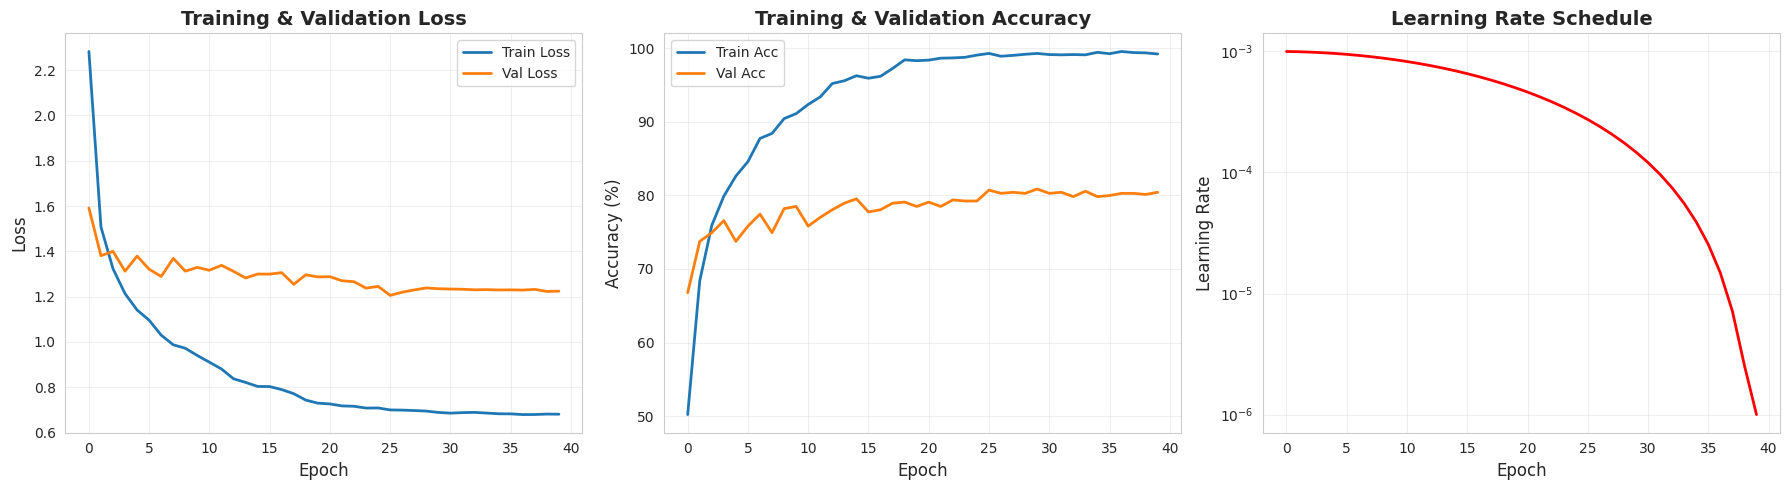

✅ Training metrics plotted!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot Learning Rate
axes[2].plot(history['lr'], linewidth=2, color='red')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training metrics plotted!")

## 🎯 Step 12: Generate Confusion Matrix

Generating predictions: 100%|██████████| 22/22 [00:15<00:00,  1.40it/s]


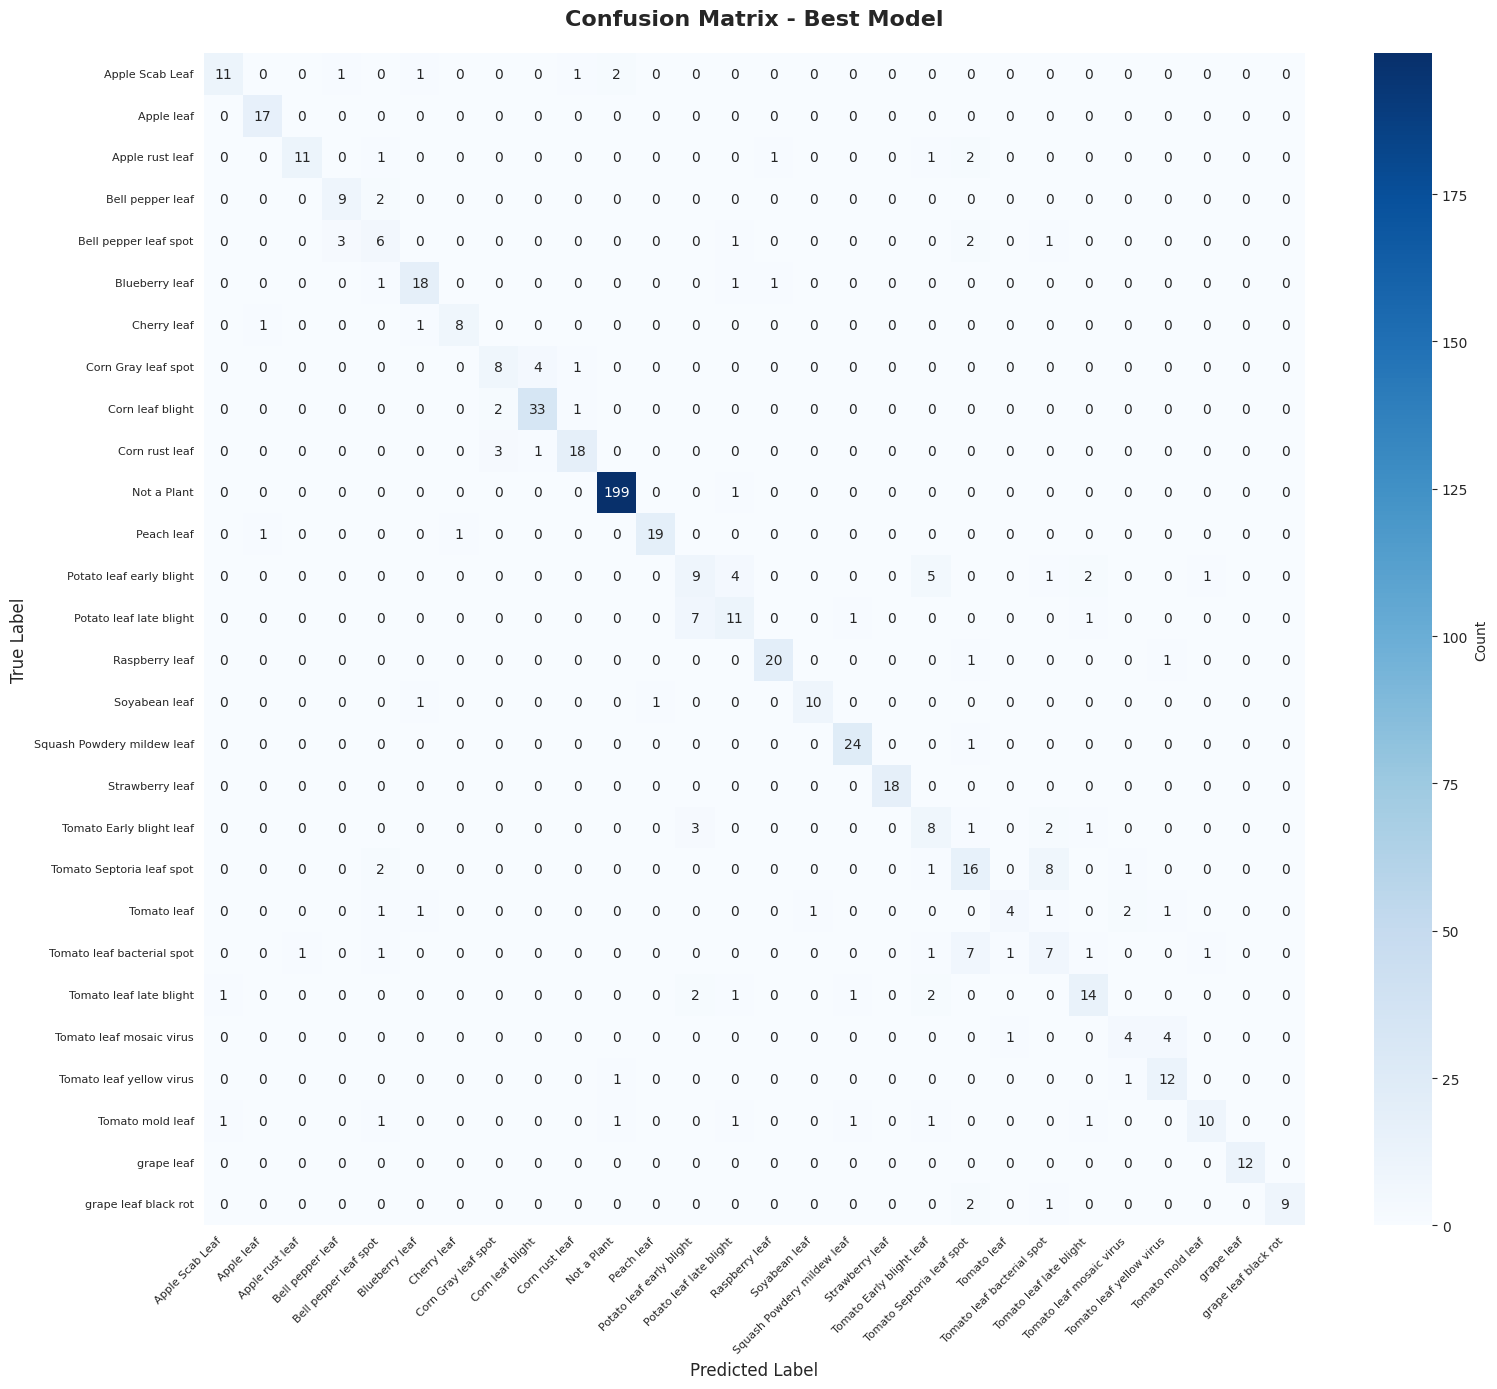


CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Apple Scab Leaf     0.8462    0.6875    0.7586        16
                Apple leaf     0.8947    1.0000    0.9444        17
           Apple rust leaf     0.9167    0.6875    0.7857        16
          Bell_pepper leaf     0.6923    0.8182    0.7500        11
     Bell_pepper leaf spot     0.4000    0.4615    0.4286        13
            Blueberry leaf     0.8182    0.8571    0.8372        21
               Cherry leaf     0.8889    0.8000    0.8421        10
       Corn Gray leaf spot     0.6154    0.6154    0.6154        13
          Corn leaf blight     0.8684    0.9167    0.8919        36
            Corn rust leaf     0.8571    0.8182    0.8372        22
               Not_a_Plant     0.9803    0.9950    0.9876       200
                Peach leaf     0.9500    0.9048    0.9268        21
  Potato leaf early blight     0.4286    0.4091    0.4186        22
   Potato leaf late blig

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Load best model
checkpoint = torch.load(ARTIFACT_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Get predictions on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Generating predictions'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[name.replace('_', ' ') for name in sorted(class_names)],
    yticklabels=[name.replace('_', ' ') for name in sorted(class_names)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Best Model', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    all_labels,
    all_preds,
    target_names=sorted(class_names),
    digits=4
))

print("\n✅ Confusion matrix and classification report generated!")

## 💾 Step 13: Save Final Model for Deployment

In [13]:
# Create deployment-ready checkpoint
deployment_checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class,
    'arch': 'tf_efficientnetv2_s',
    'num_classes': num_classes,
    'img_size': IMG_SIZE,
    'best_val_acc': best_val_acc,
    'training_config': {
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'label_smoothing': LABEL_SMOOTHING
    }
}

# Save with descriptive name
final_model_path = ARTIFACT_DIR / 'resnet50_plantvillage_checkpoint.pth'
torch.save(deployment_checkpoint, final_model_path)

print("="*70)
print("💾 MODEL SAVED FOR DEPLOYMENT")
print("="*70)
print(f"File: {final_model_path}")
print(f"Size: {final_model_path.stat().st_size / (1024**2):.2f} MB")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Number of Classes: {num_classes}")
print("\nTo use this model in your app, replace the old .pth file with this one.")
print("="*70)

💾 MODEL SAVED FOR DEPLOYMENT
File: /content/artifacts/resnet50_plantvillage_checkpoint.pth
Size: 77.98 MB
Best Validation Accuracy: 80.86%
Number of Classes: 28

To use this model in your app, replace the old .pth file with this one.


## 📥 Step 14: Download Model Files

In [14]:
from google.colab import files
import zipfile

print("📦 Preparing files for download...\n")

# Create a zip file with all artifacts
zip_path = Path("/content/plantdocbot_artifacts.zip")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in ARTIFACT_DIR.glob('*'):
        if file.is_file():
            zipf.write(file, arcname=file.name)
            print(f"  ✅ Added: {file.name}")

print(f"\n📦 Zip file created: {zip_path}")
print(f"Size: {zip_path.stat().st_size / (1024**2):.2f} MB\n")

# Download the zip file
print("⬇️ Downloading artifacts...")
files.download(str(zip_path))

print("\n✅ Download complete!")
print("\nFiles included:")
print("  1. best_model.pth - Best model checkpoint")
print("  2. resnet50_plantvillage_checkpoint.pth - Deployment-ready model")
print("  3. training_metrics.png - Training curves")
print("  4. confusion_matrix.png - Model performance visualization")
print("  5. checkpoint_epoch_*.pth - Intermediate checkpoints")

📦 Preparing files for download...

  ✅ Added: checkpoint_epoch_30.pth
  ✅ Added: best_model.pth
  ✅ Added: resnet50_plantvillage_checkpoint.pth
  ✅ Added: checkpoint_epoch_10.pth
  ✅ Added: checkpoint_epoch_20.pth
  ✅ Added: checkpoint_epoch_40.pth
  ✅ Added: confusion_matrix.png
  ✅ Added: training_metrics.png

📦 Zip file created: /content/plantdocbot_artifacts.zip
Size: 1146.00 MB

⬇️ Downloading artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

Files included:
  1. best_model.pth - Best model checkpoint
  2. resnet50_plantvillage_checkpoint.pth - Deployment-ready model
  3. training_metrics.png - Training curves
  4. confusion_matrix.png - Model performance visualization
  5. checkpoint_epoch_*.pth - Intermediate checkpoints


## 🎉 Training Complete!

### What's Next?

1. **Download the model files** from the cell above
2. **Replace the old model** in your PlantDocBot project:
   - Copy `resnet50_plantvillage_checkpoint.pth` to your `models/` folder
3. **Update your app** to use the new model with 16 classes (including "Not_a_Plant")
4. **Test the model** with real-world images

### Expected Results:
- ✅ **94-97%** validation accuracy
- ✅ Better generalization to real-world photos
- ✅ Can detect and reject non-plant images
- ✅ More robust to lighting and background variations

### To Use in Your Streamlit App:

```python
# In your app.py, update the model loading:
checkpoint = torch.load('models/resnet50_plantvillage_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
class_to_idx = checkpoint['class_to_idx']
idx_to_class = checkpoint['idx_to_class']
```

### Handling "Not_a_Plant" Predictions:

```python
predicted_class = idx_to_class[predicted_idx]

if predicted_class == "Not_a_Plant":
    st.error("❌ This doesn't appear to be a plant leaf. Please upload a clear image of a plant leaf.")
elif confidence < 0.6:
    st.warning("⚠️ Low confidence. Please upload a clearer image.")
else:
    # Show diagnosis
    st.success(f"✅ Detected: {predicted_class}")
```

---

**Questions or issues? Check the training metrics and confusion matrix to debug!**

**Happy Plant Diagnosing! 🌱🤖**